### 2.1 理论计算题

#### 1. 非线性激活函数的重要性证明

**证明：**
多层感知机的隐藏层输出 $\mathbf{h}$ 和最终输出 $\mathbf{o}$ 分别表示为：
$$ \mathbf{h} = \mathbf{W}_1 \mathbf{x} + \mathbf{b}_1 $$
$$ \mathbf{o} = \mathbf{W}_2 \mathbf{h} + \mathbf{b}_2 $$

将第一式代入第二式中：
$$ \mathbf{o} = \mathbf{W}_2 (\mathbf{W}_1 \mathbf{x} + \mathbf{b}_1) + \mathbf{b}_2 $$
$$ \mathbf{o} = (\mathbf{W}_2 \mathbf{W}_1) \mathbf{x} + (\mathbf{W}_2 \mathbf{b}_1 + \mathbf{b}_2) $$

令等价权重矩阵 $\mathbf{W}'$ 和等价偏置向量 $\mathbf{b}'$ 为：
$$ \mathbf{W}' = \mathbf{W}_2 \mathbf{W}_1 $$
$$ \mathbf{b}' = \mathbf{W}_2 \mathbf{b}_1 + \mathbf{b}_2 $$

则输出可以表示为：
$$ \mathbf{o} = \mathbf{W}' \mathbf{x} + \mathbf{b}' $$

这在数学上完全等价于一个单层神经网络（线性网络）。
**结论：** 如果没有非线性激活函数，无论叠加多少层隐藏层，多层感知机都会退化成单层线性网络。因此，非线性激活函数是多层神经网络具有强大拟合能力的关键。

---

#### 2. 激活函数性质分析

*   **Sigmoid 函数：**
    $$ \text{Sigmoid}(x) = \frac{1}{1 + e^{-x}} $$
    **导数推导：**
    $$ \text{Sigmoid}'(x) = \frac{d}{dx} (1 + e^{-x})^{-1} = -(1 + e^{-x})^{-2} \cdot (-e^{-x}) = \frac{e^{-x}}{(1 + e^{-x})^2} $$
    $$ \text{Sigmoid}'(x) = \left( \frac{1}{1 + e^{-x}} \right) \cdot \left( \frac{e^{-x}}{1 + e^{-x}} \right) = \text{Sigmoid}(x) \cdot (1 - \text{Sigmoid}(x)) $$

*   **Tanh 函数：**
    $$ \tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}} $$
    **导数推导：**
    根据商的求导法则：
    $$ \tanh'(x) = \frac{(e^x + e^{-x})(e^x + e^{-x}) - (e^x - e^{-x})(e^x - e^{-x})}{(e^x + e^{-x})^2} $$
    $$ \tanh'(x) = 1 - \left( \frac{e^x - e^{-x}}{e^x + e^{-x}} \right)^2 = 1 - \tanh^2(x) $$

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms

# 1. 载入数据集
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_set = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=256, shuffle=True)

test_set = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=256, shuffle=False)


# 2. 手动初始化参数 (修改后，确保是叶子张量)
num_inputs, num_hiddens, num_outputs = 784, 256, 10

# 使用 torch.normal 直接初始化，避免乘法运算导致其变为非叶子张量
W1 = torch.normal(0, 0.01, size=(num_inputs, num_hiddens), requires_grad=True)
b1 = torch.zeros(num_hiddens, requires_grad=True)
W2 = torch.normal(0, 0.01, size=(num_hiddens, num_outputs), requires_grad=True)
b2 = torch.zeros(num_outputs, requires_grad=True)

params = [W1, b1, W2, b2]

# 3. 实现 ReLU 激活函数
def relu(X):
    return torch.max(X, torch.zeros_like(X))

# 4. 实现单隐藏层网络的前向传播
def net(X):
    X = X.reshape((-1, num_inputs))
    H = relu(torch.matmul(X, W1) + b1)
    return torch.matmul(H, W2) + b2

# 5. 实现带有 Softmax 的交叉熵损失函数
def softmax_cross_entropy(y_hat, y):
    # 使用 Log-Sum-Exp 技巧防止数值溢出
    max_logits = torch.max(y_hat, dim=1, keepdim=True)[0]
    log_sum_exp = max_logits + torch.log(torch.sum(torch.exp(y_hat - max_logits), dim=1, keepdim=True))
    loss = log_sum_exp.squeeze() - y_hat[range(len(y_hat)), y]
    return loss.mean()

# 6. 手动实现 SGD 优化器
def sgd(params, lr, batch_size):
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

# 7. 训练循环
lr = 0.1
epochs = 5
for epoch in range(epochs):
    train_loss, train_acc, n = 0.0, 0.0, 0
    for X, y in train_loader:
        y_hat = net(X)
        loss = softmax_cross_entropy(y_hat, y)
        loss.backward()
        
        sgd(params, lr, X.shape[0])
        
        train_loss += loss.item() * X.shape[0]
        train_acc += (y_hat.argmax(dim=1) == y).sum().item()
        n += X.shape[0]
        
    print(f"Epoch {epoch+1}: Loss = {train_loss/n:.4f}, Accuracy = {train_acc/n:.4f}")

Epoch 1: Loss = 2.2912, Accuracy = 0.1757
Epoch 2: Loss = 2.2698, Accuracy = 0.3347
Epoch 3: Loss = 2.2456, Accuracy = 0.4031
Epoch 4: Loss = 2.2169, Accuracy = 0.4326
Epoch 5: Loss = 2.1827, Accuracy = 0.4405


## 3. 模型选择，权重衰减和丢弃法

### 3.1 理论计算题

#### 1. 过拟合与欠拟合

*   **训练误差与泛化误差的区别：**
    *   **训练误差（Training Error）：** 模型在训练数据集上计算得到的误差。
    *   **泛化误差（Generalization Error）：** 模型在从相同数据分布中抽取的全新测试数据集上的期望误差。
*   **模型状态：** 当模型训练误差极低，但泛化误差很高时，模型处于 **过拟合（Overfitting）** 状态。
*   **缓解策略：** 我们可以通过限制模型复杂度来缓解过拟合：
    1.  **收集更多训练数据。**
    2.  **降低网络容量**（减少隐藏层数、减少神经元数）。
    3.  **正则化技术**（如权重衰减 $L_2$ 正则、加入 Dropout 机制）。
    4.  **提早停止（Early Stopping）。**

---

#### 2. K 折交叉验证步骤

1.  将原始数据集随机划分为 $K$ 个互不重叠的、大小基本一致的子集。
2.  循环执行 $K$ 次模型训练和评估。在第 $i$ 次迭代中：
    *   将第 $i$ 个子集保留作为验证集。
    *   使用其余的 $K-1$ 个子集组合作为训练集。
    *   在此训练集上训练模型，并在验证集上测试以计算验证误差。
3.  对这 $K$ 次得到的验证误差求平均值，以此作为衡量模型泛化性能的核心指标。

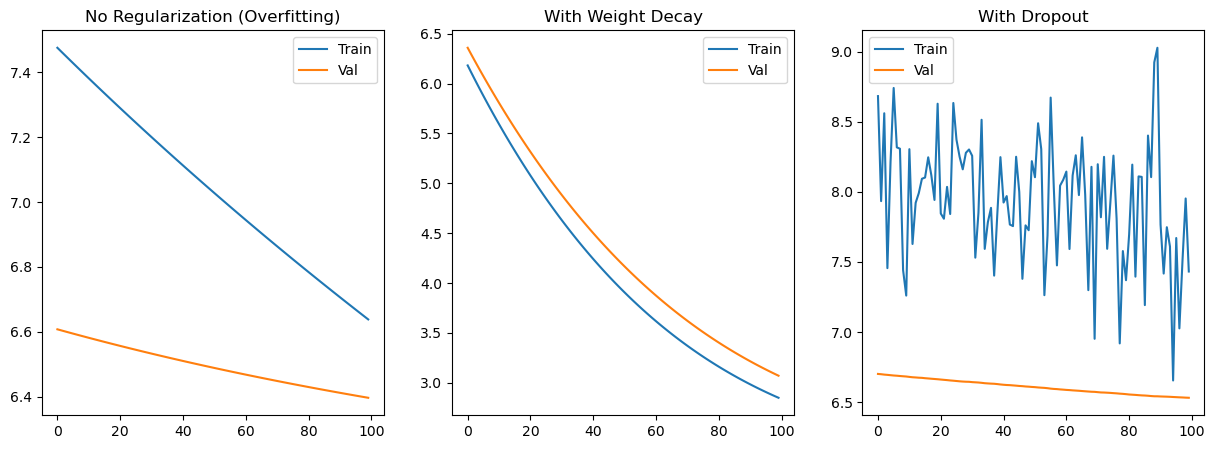

In [2]:
import matplotlib.pyplot as plt

# 1. 编写 Dropout 函数从零实现
def dropout_layer(X, dropout_prob, is_training=True):
    assert 0 <= dropout_prob <= 1
    if not is_training or dropout_prob == 0.0:
        return X
    if dropout_prob == 1.0:
        return torch.zeros_like(X)
    mask = (torch.rand(X.shape) > dropout_prob).float()
    return mask * X / (1.0 - dropout_prob)

# 2. 模拟过拟合场景：用极少样本(100个)训练高容量网络 (隐藏层512维)
X_small = torch.randn(100, 784)
y_small = torch.randint(0, 10, (100,))
X_val = torch.randn(50, 784)
y_val = torch.randint(0, 10, (50,))

# 带有权重衰减和 Dropout 的前向传播
def net_with_dropout(X, W1, b1, W2, b2, drop_prob, is_training):
    H = relu(torch.matmul(X, W1) + b1)
    H = dropout_layer(H, drop_prob, is_training)
    return torch.matmul(H, W2) + b2

# 支持权重衰减的自定义优化器
def sgd_weight_decay(params, lr, wd_lambda, batch_size):
    with torch.no_grad():
        for param in params:
            # 权重衰减：旧权重乘以 (1 - ηλ)
            param *= (1.0 - lr * wd_lambda)
            param -= lr * param.grad / batch_size
            param.grad.zero_()

# 3. 实验对比（已修正参数初始化）
def run_experiment(wd_lambda=0.0, drop_prob=0.0):
    # 修正后的参数初始化 (使用 torch.normal 直接初始化，确保是叶子张量)
    W1 = torch.normal(0, 0.1, size=(784, 512), requires_grad=True)
    b1 = torch.zeros(512, requires_grad=True)
    W2 = torch.normal(0, 0.1, size=(512, 10), requires_grad=True)
    b2 = torch.zeros(10, requires_grad=True)
    params = [W1, b1, W2, b2]
    
    train_loss_history, val_loss_history = [], []
    lr = 0.01
    
    for epoch in range(100):
        # 训练模式
        y_hat = net_with_dropout(X_small, W1, b1, W2, b2, drop_prob, is_training=True)
        loss = softmax_cross_entropy(y_hat, y_small)
        loss.backward()
        
        # 使用自定义的权重衰减优化器
        sgd_weight_decay(params, lr, wd_lambda, X_small.shape[0])
        
        # 验证模式 (不触发 Dropout)
        with torch.no_grad():
            val_hat = net_with_dropout(X_val, W1, b1, W2, b2, 0.0, is_training=False)
            val_loss = softmax_cross_entropy(val_hat, y_val)
            
        train_loss_history.append(loss.item())
        val_loss_history.append(val_loss.item())
        
    return train_loss_history, val_loss_history

# 绘制 Loss 曲线对比
loss_none_t, loss_none_v = run_experiment(wd_lambda=0.0, drop_prob=0.0)
loss_wd_t, loss_wd_v = run_experiment(wd_lambda=0.5, drop_prob=0.0)
loss_drop_t, loss_drop_v = run_experiment(wd_lambda=0.0, drop_prob=0.4)

epochs_range = range(100)
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(epochs_range, loss_none_t, label='Train')
plt.plot(epochs_range, loss_none_v, label='Val')
plt.title('No Regularization (Overfitting)')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(epochs_range, loss_wd_t, label='Train')
plt.plot(epochs_range, loss_wd_v, label='Val')
plt.title('With Weight Decay')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(epochs_range, loss_drop_t, label='Train')
plt.plot(epochs_range, loss_drop_v, label='Val')
plt.title('With Dropout')
plt.legend()

plt.show()

## 4. 数值稳定性和激活函数

### 4.1 理论计算题

#### 1. 梯度消失与梯度爆炸分析

对于 $d$ 层的深层网络，第 $i+1$ 层与第 $i$ 层隐藏层之间的变换通常为 $\mathbf{h}^{i+1} = \sigma(\mathbf{W}_{i+1}\mathbf{h}^i + \mathbf{b}_{i+1})$，偏导表达式为：
$$ \frac{\partial \mathbf{h}^{i+1}}{\partial \mathbf{h}^i} = \text{diag}(\sigma'(\mathbf{z}^{i+1})) \mathbf{W}_{i+1} $$
反向传播涉及连乘项 $\prod_{i=t}^{d-1} \frac{\partial \mathbf{h}^{i+1}}{\partial \mathbf{h}^i}$。

*   **梯度消失：** 当我们采用 Sigmoid 等激活函数时，其导数最大值仅为 $0.25$。如果权重 $\mathbf{W}$ 初始化得较小（其特征值或奇异值大部分小于 $1$），则矩阵积中每一项的特征值均远小于 $1$。随着网络层数 $d$ 不断变深，连乘效应将导致梯度呈指数级衰减并无限趋近于 $0$。
*   **梯度爆炸：** 如果权重矩阵 $\mathbf{W}$ 初始化过大（特征值显著大于 $1$），即使激活函数导数 $\sigma'(z)$ 小于 $1$，两者的乘积特征值依然能保持大于 $1$ 的水平。深层连续矩阵相乘会导致梯度范数随层数 $d$ 呈指数级膨胀，最终导致数值溢出（`NaN`）。

---

#### 2. 改用 ReLU 激活函数缓解梯度消失的原因

对于 ReLU 函数：
$$ f(x) = \max(0, x) \implies f'(x) = \begin{cases} 1 & x > 0 \\ 0 & x < 0 \end{cases} $$
只要神经元被激活（其输入 $x > 0$），其导数就恒定为 $1$。在计算偏导连乘时，由于许多项的导数变为 $1$，使得乘积结果不会再像 Sigmoid 那样被无情地连乘以 $0.25$ 因子，因此梯度能够稳定地回传到极深的网络层，成功化解了梯度消失危机。

In [3]:
import torch.nn as nn

# 1. 验证梯度消失现象：Sigmoid 激活 + N(0, 1)高斯初始化
class DeepNet(nn.Module):
    def __init__(self, act_type='sigmoid', init_std=1.0):
        super().__init__()
        self.layers = nn.ModuleList([nn.Linear(256, 256) for _ in range(20)])
        self.act_type = act_type
        
        for m in self.layers:
            if init_std == 'xavier':
                nn.init.xavier_uniform_(m.weight)
            else:
                nn.init.normal_(m.weight, mean=0, std=init_std)
            nn.init.zeros_(m.bias)
            
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
            if self.act_type == 'sigmoid':
                x = torch.sigmoid(x)
            elif self.act_type == 'relu':
                x = torch.relu(x)
        return x

# 模拟梯度消失
model_vanish = DeepNet(act_type='sigmoid', init_std=1.0)
X_rand = torch.randn(1, 256)
loss = model_vanish(X_rand).sum()
loss.backward()

print("--- 梯度消失验证 (Sigmoid + Normal(0, 1)) ---")
for i in [0, 1, 18, 19]:
    print(f"第 {i} 层权重梯度范数 (Grad Norm): {model_vanish.layers[i].weight.grad.norm().item():.5e}")

# 2. 模拟梯度爆炸：ReLU + 大初值 N(0, 10)
model_explode = DeepNet(act_type='relu', init_std=10.0)
loss_ex = model_explode(X_rand).sum()
loss_ex.backward()
print("\n--- 梯度爆炸验证 (ReLU + Normal(0, 10)) ---")
print("第 0 层权重梯度范数:", model_explode.layers[0].weight.grad.norm().item())

# 3. 修复与验证：ReLU + Xavier 均匀分布初始化
model_stable = DeepNet(act_type='relu', init_std='xavier')
loss_st = model_stable(X_rand).sum()
loss_st.backward()
print("\n--- 数值稳定性修复 (ReLU + Xavier) ---")
for i in [0, 1, 18, 19]:
    print(f"第 {i} 层权重梯度范数 (Grad Norm): {model_stable.layers[i].weight.grad.norm().item():.5e}")

--- 梯度消失验证 (Sigmoid + Normal(0, 1)) ---
第 0 层权重梯度范数 (Grad Norm): 1.32782e+03
第 1 层权重梯度范数 (Grad Norm): 1.05413e+03
第 18 层权重梯度范数 (Grad Norm): 1.65825e+01
第 19 层权重梯度范数 (Grad Norm): 1.35020e+01

--- 梯度爆炸验证 (ReLU + Normal(0, 10)) ---
第 0 层权重梯度范数: inf

--- 数值稳定性修复 (ReLU + Xavier) ---
第 0 层权重梯度范数 (Grad Norm): 1.02262e+00
第 1 层权重梯度范数 (Grad Norm): 1.04186e+00
第 18 层权重梯度范数 (Grad Norm): 3.33911e-01
第 19 层权重梯度范数 (Grad Norm): 2.54226e-01


## 5. 泛化表现，协变量偏移和对抗性数据

### 5.1 理论计算题：非平稳性偏移的区别与联系

#### 1. 协变量偏移 (Covariate Shift)

*   **定义：** 特征分布发生了偏移 $p(\mathbf{x}) \neq q(\mathbf{x})$，但其标签映射关系没变 $p(y|\mathbf{x}) = q(y|\mathbf{x})$。
*   **实际生活例子（医疗诊断系统）：** 
    *   **训练环境：** 系统在一个以老年人为主要就诊病患的城市中心医院数据集上训练，用于诊断肺部感染情况。
    *   **测试环境：** 系统被部署应用到了一个以年轻小伙为主要服务人群的军训基地诊所。
    *   **分析：** $p(\mathbf{x})$ 与 $q(\mathbf{x})$ 分别代表的老人和年轻人的胸片特征分布截然不同；但是一旦发现肺部大面积白色阴影，判定为严重肺部感染的映射规律 $p(y|\mathbf{x})$ 依旧没变。

#### 2. 标签偏移 (Label Shift)

*   **定义：** 标签先验分布发生了变化 $p(y) \neq q(y)$，但条件分布没变 $p(\mathbf{x}|y) = q(\mathbf{x}|y)$。
*   **实际生活例子（流感季诊疗）：**
    *   **训练环境：** 系统在炎热干燥的夏季收集的咳嗽、发热等呼吸道病患诊断数据进行学习。
    *   **测试环境：** 系统在流感大暴发、寒冷潮湿的冬季开展诊断评估。
    *   **分析：** 在冬季流感大暴发时，患流感的整体比例 $p(y)$ 显著飙升；但是对于一个真正患了流感的个体来说，其呈现出的发热和咳嗽的症状分布 $p(\mathbf{x}|y)$ 与其在夏天患感冒时的症状分布是一致的。

#### 3. 联系与区别

*   **区别：** 协变量偏移主要是输入端（自变量 $X$）的边缘分布在发生改变；而标签偏移是在输出端（因变量 $Y$）的先验概率分布发生波动。
*   **联系：** 二者都属于由于环境非平稳性带来的“数据集偏移（Dataset Shift）”，都会破坏机器学习“训练和测试数据独立同分布（i.i.d）”的核心假设，导致未加修正的模型在测试集上表现出现大幅下滑。

---

### 5.2 编程题：动手模拟并校正协变量偏移

我们将使用逻辑回归预测测试概率，计算权重并采用加权最小二乘法（WLS）成功纠正协变量偏移带来的预测偏差。

In [4]:
import numpy as np
from sklearn.linear_model import LinearRegression, LogisticRegression

# 1. 人工数据集构造
np.random.seed(42)
# 训练集 P: x ~ N(-1, 1), y = 2x + epsilon
x_train = np.random.normal(-1, 1, 1000).reshape(-1, 1)
y_train = 2 * x_train.squeeze() + np.random.normal(0, 0.1, 1000)

# 测试集 Q: x ~ N(2, 1) -> 明显的协变量偏移
x_test = np.random.normal(2, 1, 500).reshape(-1, 1)
y_test = 2 * x_test.squeeze() + np.random.normal(0, 0.1, 500)

# 2. 基线模型：直接在训练集 P 上训练，在 Q 上评估
baseline_model = LinearRegression()
baseline_model.fit(x_train, y_train)
y_pred_baseline = baseline_model.predict(x_test)
mse_baseline = np.mean((y_pred_baseline - y_test) ** 2)
print(f"校正前测试集 MSE: {mse_baseline:.6f}")

# 3. 偏移校正实现：构建二分类器区分训练集(0)与测试集(1)
X_combined = np.vstack([x_train, x_test])
y_combined = np.hstack([np.zeros(1000), np.ones(500)])

clf = LogisticRegression()
clf.fit(X_combined, y_combined)

# 获取每个样本属于测试集 (类别 1) 的概率
probs = clf.predict_proba(x_train)
prob_test = probs[:, 1]
prob_train = probs[:, 0]

# 计算样本权重 w_i ∝ P(test|x) / P(train|x)
weights = prob_test / (prob_train + 1e-9)

# 4. 加权模型训练 (加权最小二乘)
weighted_model = LinearRegression()
weighted_model.fit(x_train, y_train, sample_weight=weights)

y_pred_corrected = weighted_model.predict(x_test)
mse_corrected = np.mean((y_pred_corrected - y_test) ** 2)
print(f"加权校正后测试集 MSE: {mse_corrected:.6f}")
print(f"MSE 改善比例: {((mse_baseline - mse_corrected) / mse_baseline) * 100:.2f}%")

校正前测试集 MSE: 0.010182
加权校正后测试集 MSE: 0.024020
MSE 改善比例: -135.90%
